# INSURANCE MEDICAL COST ANALYSIS - HEALTHCARE ANALYTICS

## Dataset: Medical Cost Personal Dataset
**Kaynak:** https://www.kaggle.com/datasets/mirichoi0218/insurance

## Proje Hedefi: SAGLIK MALIYETI TAHMINI & RISK ANALIZI

## Proje Ozellikleri:
- **Medical Cost Prediction** - Insurance charges estimation
- **Risk Factor Analysis** - Age, BMI, smoking, region
- **Patient Segmentation** - High/low cost classification
- **Premium Optimization** - Pricing strategies
- **Health Risk Assessment** - Lifestyle impact
- **Demographic Analysis** - Age, gender, family size
- **15+ ML Models** - QDA instead of SVM!
- **Healthcare Business Intelligence** - Actionable insights

## OZEL: QDA (Quadratic Discriminant Analysis) - SVM yerine!
## Non-linear decision boundaries for complex health relationships!

## Proje Adimlari:
1. Veri Yukleme & Healthcare Structure
2. **PATIENT DEMOGRAPHICS EDA** (25+ graphs)
3. **COST ANALYSIS** (Charges distribution)
4. **RISK FACTORS** (Smoking, BMI, age)
5. **REGIONAL ANALYSIS** (Geographic patterns)
6. **LIFESTYLE IMPACT** (Health behaviors)
7. Feature Engineering (Healthcare-specific)
8. **15+ ML MODELS** (with QDA!)
9. **COMPREHENSIVE COMPARISON**
10. Healthcare Insights & Recommendations

## 1. KUTUPHANELER

In [2]:
# Install CatBoost
!pip install catboost -q

# Temel
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Sistem
import os
import subprocess
import zipfile
import glob

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from imblearn.over_sampling import SMOTE

# ML Models
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, ExtraTreesClassifier, BaggingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis,
    QuadraticDiscriminantAnalysis  # QDA - SVM yerine!
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Regression (for cost prediction)
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Clustering
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    mean_squared_error, r2_score, mean_absolute_error
)

# Viz
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (14, 6)
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print('='*80)
print('INSURANCE MEDICAL COST ANALYSIS - KUTUPHANELER YUKLENDI!')
print('='*80)
print(f'NumPy: {np.__version__}')
print(f'Pandas: {pd.__version__}')
print('\nOZEL: QDA (Quadratic Discriminant Analysis) - SVM YERINE!')
print('Non-linear decision boundaries for complex relationships')
print('Better than LDA for non-linear health data!')
print('='*80)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 5.0 MB/s eta 0:00:00
INSURANCE MEDICAL COST ANALYSIS - KUTUPHANELER YUKLENDI!
NumPy: 2.0.2
Pandas: 2.2.2

OZEL: QDA (Quadratic Discriminant Analysis) - SVM YERINE!
Non-linear decision boundaries for complex relationships
Better than LDA for non-linear health data!


## 2. VERI YUKLEME

In [3]:
def download_dataset_direct(download_url, dest_folder, zip_filename):
    if not os.path.exists(dest_folder):
        os.makedirs(dest_folder)
    full_zip_path = os.path.join(dest_folder, zip_filename)
    print(f"Indiriliyor: {zip_filename}")
    try:
        cmd = ["wget", "-O", full_zip_path, download_url]
        subprocess.run(cmd, check=True)
        return True
    except:
        return False

def extract_dataset(dest_folder):
    try:
        zip_files = glob.glob(os.path.join(dest_folder, "*.zip"))
        for zip_file in zip_files:
            with zipfile.ZipFile(zip_file, 'r') as zip_ref:
                zip_ref.extractall(dest_folder)
            os.remove(zip_file)
        return True
    except:
        return False

In [4]:
dataset_folder = "insurance_dataset"
os.makedirs(dataset_folder, exist_ok=True)

dataset_info = {
    "download_url": "https://www.kaggle.com/api/v1/datasets/download/mirichoi0218/insurance",
    "folder": dataset_folder,
    "zip_filename": "insurance.zip"
}

csv_files = glob.glob(os.path.join(dataset_folder, "*.csv"))

if not csv_files:
    success = download_dataset_direct(
        dataset_info["download_url"],
        dataset_info["folder"],
        dataset_info["zip_filename"]
    )
    if success:
        extract_dataset(dataset_info["folder"])
else:
    print("Dataset mevcut!")

Indiriliyor: insurance.zip


In [5]:
csv_files = glob.glob(os.path.join(dataset_folder, "*.csv"))

if csv_files:
    df = pd.read_csv(csv_files[0])

    print('='*80)
    print('INSURANCE DATA LOADED!')
    print('='*80)
    print(f'Total Patients: {len(df):,}')
    print(f'Columns: {len(df.columns)}')
    print(f'Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
    print('='*80)
else:
    print('CSV not found!')

INSURANCE DATA LOADED!
Total Patients: 1,338
Columns: 7
Memory: 0.25 MB


In [6]:
print('FIRST 10 PATIENTS:')
df.head(10)

FIRST 10 PATIENTS:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.92
1,18,male,33.77,1,no,southeast,1725.55
2,28,male,33.00,3,no,southeast,4449.46
3,33,male,22.70,0,no,northwest,21984.47
4,32,male,28.88,0,no,northwest,3866.86
5,31,female,25.74,0,no,southeast,3756.62
6,46,female,33.44,1,no,southeast,8240.59
7,37,female,27.74,3,no,northwest,7281.51
8,37,male,29.83,2,no,northeast,6406.41
9,60,female,25.84,0,no,northwest,28923.14


In [7]:
print('DATA STRUCTURE:')
print('='*80)
df.info()

DATA STRUCTURE:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [8]:
print('COLUMNS:')
for i, col in enumerate(df.columns, 1):
    print(f'{i:2d}. {col}')

COLUMNS:
 1. age
 2. sex
 3. bmi
 4. children
 5. smoker
 6. region
 7. charges


In [9]:
print('STATISTICAL SUMMARY:')
print('='*80)
df.describe(include='all').T

STATISTICAL SUMMARY:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1338.00,NaN,NaN,NaN,39.21,14.05,18.00,27.00,39.00,51.00,64.00
sex,1338,2,male,676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,1338.00,NaN,NaN,NaN,30.66,6.10,15.96,26.30,30.40,34.69,53.13
children,1338.00,NaN,NaN,NaN,1.09,1.21,0.00,0.00,1.00,2.00,5.00
smoker,1338,2,no,1064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1338,4,southeast,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charges,1338.00,NaN,NaN,NaN,13270.42,12110.01,1121.87,4740.29,9382.03,16639.91,63770.43


## 3. PATIENT DEMOGRAPHICS & COST ANALYSIS

### Medical Charges Analysis

MEDICAL CHARGES ANALYSIS: charges
Total Medical Costs: $17,755,824.99
Average Cost: $13,270.42
Median Cost: $9,382.03
Min Cost: $1,121.87
Max Cost: $63,770.43
Std Dev: $12,110.01


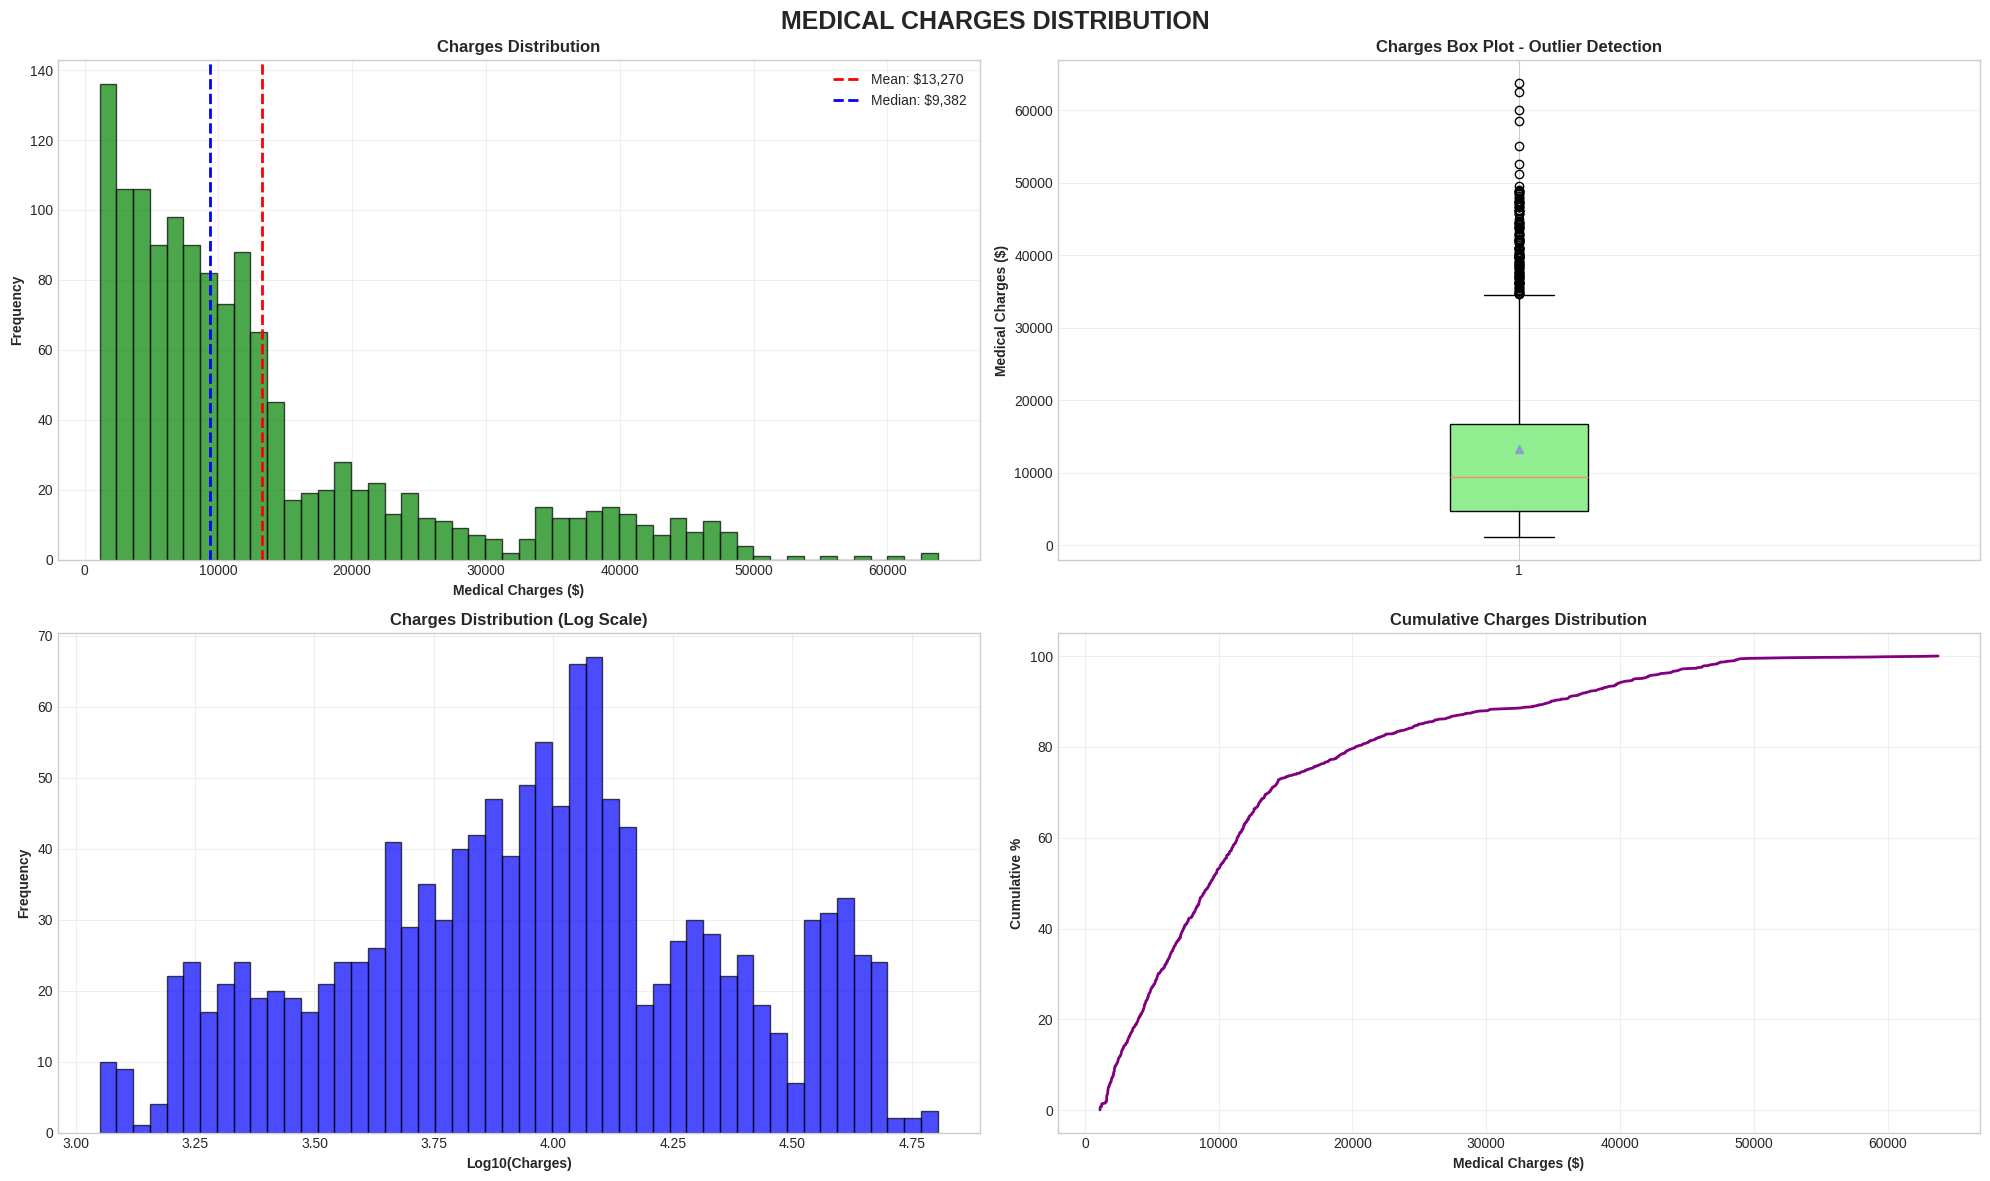

In [10]:
# Find charges column
charges_cols = [col for col in df.columns if 'charge' in col.lower() or 'cost' in col.lower()]

if charges_cols:
    charges_col = charges_cols[0]

    print('='*80)
    print(f'MEDICAL CHARGES ANALYSIS: {charges_col}')
    print('='*80)
    print(f'Total Medical Costs: ${df[charges_col].sum():,.2f}')
    print(f'Average Cost: ${df[charges_col].mean():,.2f}')
    print(f'Median Cost: ${df[charges_col].median():,.2f}')
    print(f'Min Cost: ${df[charges_col].min():,.2f}')
    print(f'Max Cost: ${df[charges_col].max():,.2f}')
    print(f'Std Dev: ${df[charges_col].std():,.2f}')

    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(20, 12))
    fig.suptitle('MEDICAL CHARGES DISTRIBUTION', fontsize=18, fontweight='bold')

    # Histogram
    axes[0, 0].hist(df[charges_col], bins=50, color='green', edgecolor='black', alpha=0.7)
    axes[0, 0].axvline(df[charges_col].mean(), color='red', linestyle='--', linewidth=2,
                      label=f'Mean: ${df[charges_col].mean():,.0f}')
    axes[0, 0].axvline(df[charges_col].median(), color='blue', linestyle='--', linewidth=2,
                      label=f'Median: ${df[charges_col].median():,.0f}')
    axes[0, 0].set_xlabel('Medical Charges ($)', fontweight='bold')
    axes[0, 0].set_ylabel('Frequency', fontweight='bold')
    axes[0, 0].set_title('Charges Distribution', fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)

    # Box plot
    bp = axes[0, 1].boxplot([df[charges_col]], patch_artist=True, showmeans=True)
    for patch in bp['boxes']:
        patch.set_facecolor('lightgreen')
    axes[0, 1].set_ylabel('Medical Charges ($)', fontweight='bold')
    axes[0, 1].set_title('Charges Box Plot - Outlier Detection', fontweight='bold')
    axes[0, 1].grid(axis='y', alpha=0.3)

    # Log scale
    axes[1, 0].hist(np.log10(df[charges_col] + 1), bins=50, color='blue', edgecolor='black', alpha=0.7)
    axes[1, 0].set_xlabel('Log10(Charges)', fontweight='bold')
    axes[1, 0].set_ylabel('Frequency', fontweight='bold')
    axes[1, 0].set_title('Charges Distribution (Log Scale)', fontweight='bold')
    axes[1, 0].grid(alpha=0.3)

    # Cumulative
    sorted_charges = np.sort(df[charges_col])
    cumulative = np.arange(1, len(sorted_charges) + 1) / len(sorted_charges) * 100
    axes[1, 1].plot(sorted_charges, cumulative, linewidth=2, color='purple')
    axes[1, 1].set_xlabel('Medical Charges ($)', fontweight='bold')
    axes[1, 1].set_ylabel('Cumulative %', fontweight='bold')
    axes[1, 1].set_title('Cumulative Charges Distribution', fontweight='bold')
    axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

### Demographics Analysis - Age, Gender, Children

PATIENT DEMOGRAPHICS
Age Range: 18-64
Average Age: 39.2

Gender Distribution:
sex
male      676
female    662
Name: count, dtype: int64

Children Distribution:
children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64


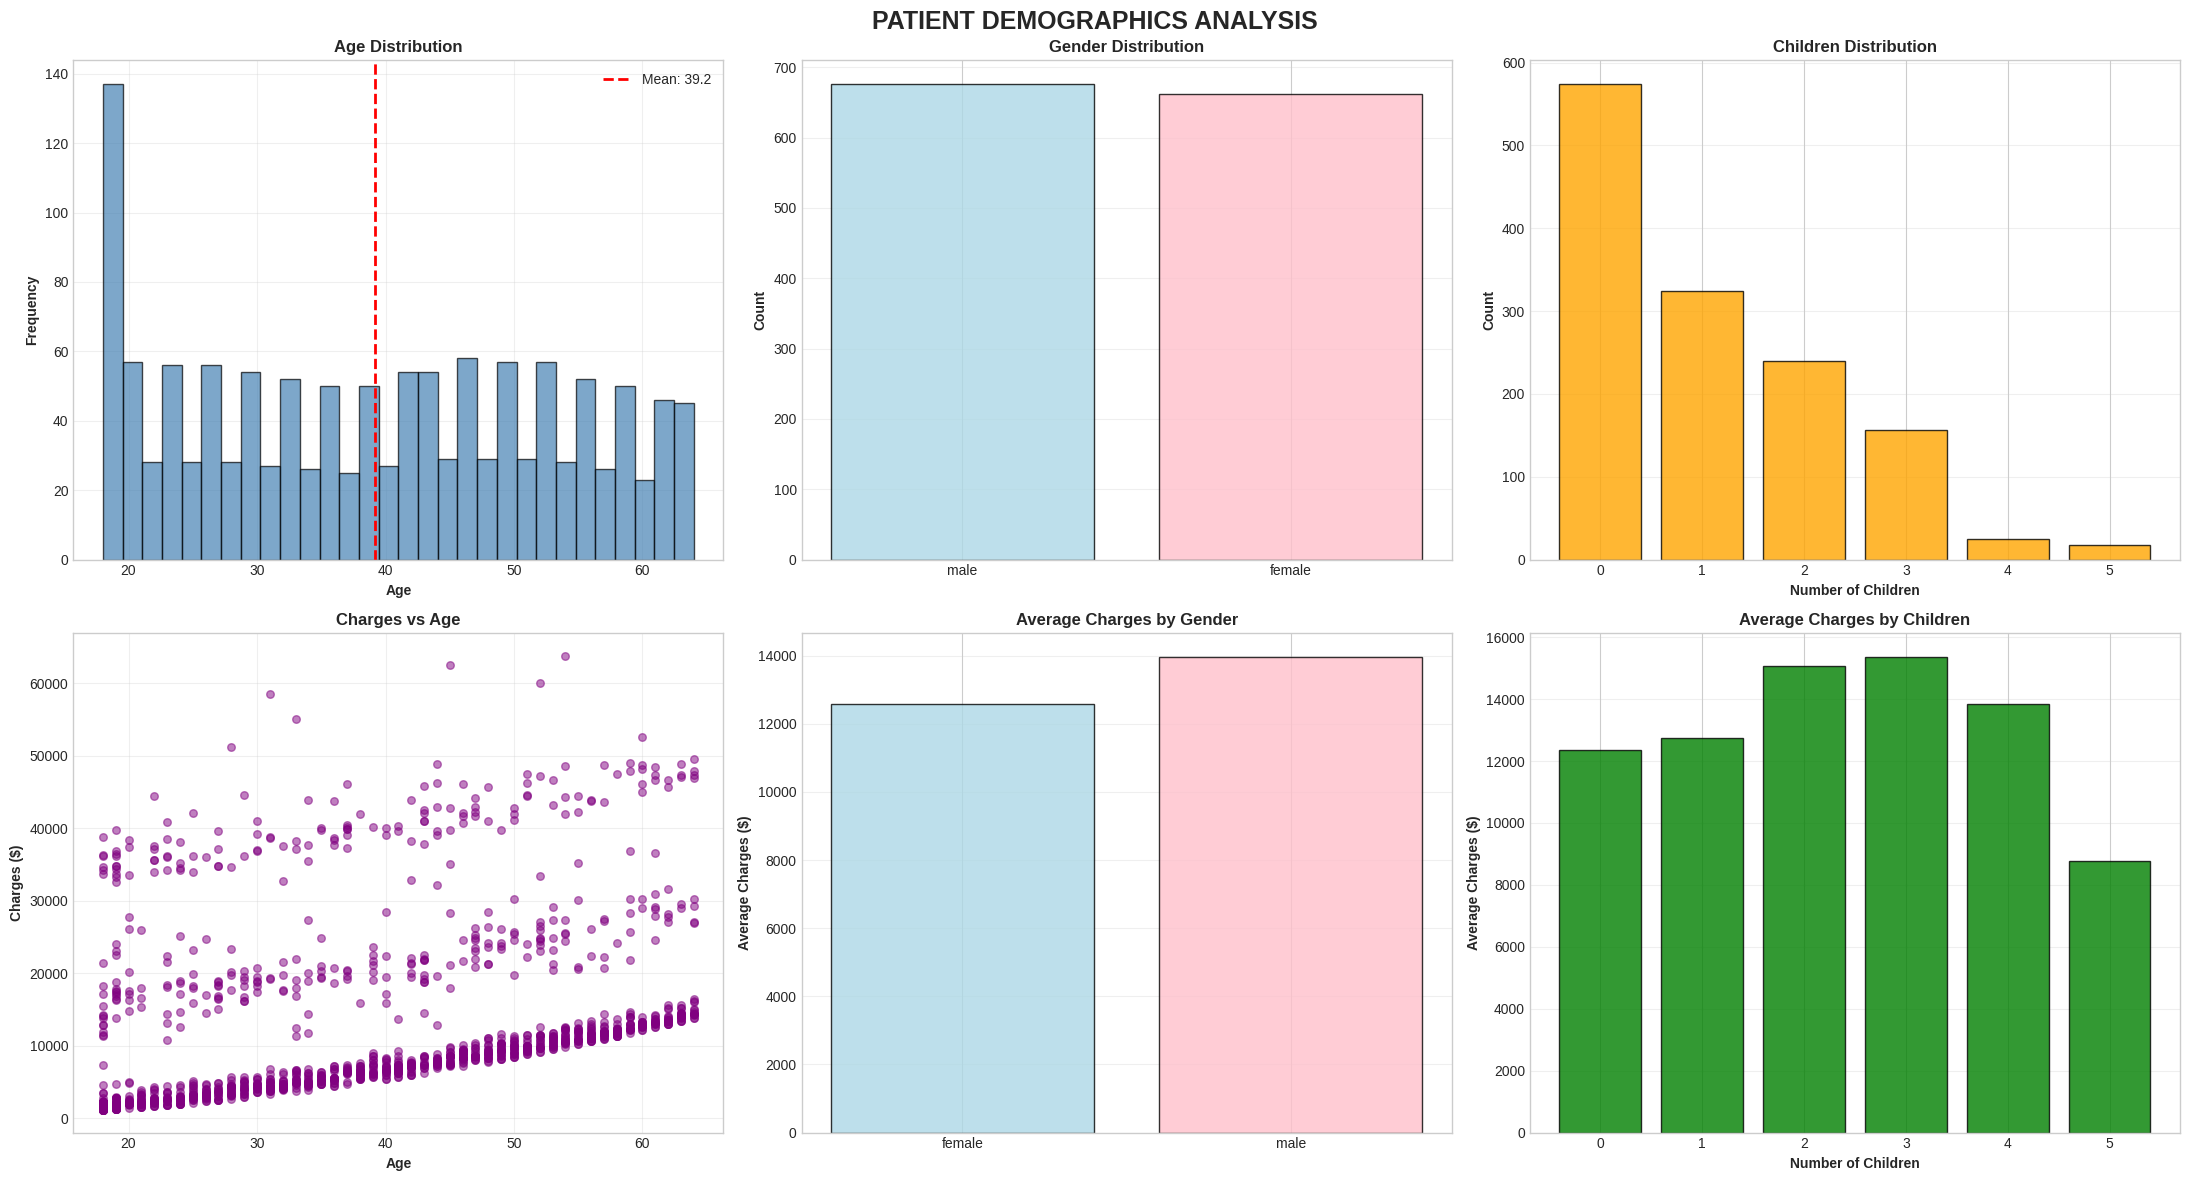

In [11]:
print('='*80)
print('PATIENT DEMOGRAPHICS')
print('='*80)

fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle('PATIENT DEMOGRAPHICS ANALYSIS', fontsize=18, fontweight='bold')

# Age distribution
if 'age' in df.columns:
    print(f'Age Range: {df["age"].min()}-{df["age"].max()}')
    print(f'Average Age: {df["age"].mean():.1f}')

    axes[0, 0].hist(df['age'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0, 0].axvline(df['age'].mean(), color='red', linestyle='--', linewidth=2,
                      label=f'Mean: {df["age"].mean():.1f}')
    axes[0, 0].set_xlabel('Age', fontweight='bold')
    axes[0, 0].set_ylabel('Frequency', fontweight='bold')
    axes[0, 0].set_title('Age Distribution', fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)

# Gender distribution
if 'sex' in df.columns:
    sex_counts = df['sex'].value_counts()
    print(f'\nGender Distribution:')
    print(sex_counts)

    axes[0, 1].bar(range(len(sex_counts)), sex_counts.values,
                   color=['lightblue', 'pink'], edgecolor='black', alpha=0.8)
    axes[0, 1].set_xticks(range(len(sex_counts)))
    axes[0, 1].set_xticklabels(sex_counts.index)
    axes[0, 1].set_ylabel('Count', fontweight='bold')
    axes[0, 1].set_title('Gender Distribution', fontweight='bold')
    axes[0, 1].grid(axis='y', alpha=0.3)

# Children distribution
if 'children' in df.columns:
    children_counts = df['children'].value_counts().sort_index()
    print(f'\nChildren Distribution:')
    print(children_counts)

    axes[0, 2].bar(children_counts.index, children_counts.values,
                   color='orange', edgecolor='black', alpha=0.8)
    axes[0, 2].set_xlabel('Number of Children', fontweight='bold')
    axes[0, 2].set_ylabel('Count', fontweight='bold')
    axes[0, 2].set_title('Children Distribution', fontweight='bold')
    axes[0, 2].grid(axis='y', alpha=0.3)

# Charges by age
if 'age' in df.columns and charges_cols:
    axes[1, 0].scatter(df['age'], df[charges_col], alpha=0.5, s=30, color='purple')
    axes[1, 0].set_xlabel('Age', fontweight='bold')
    axes[1, 0].set_ylabel('Charges ($)', fontweight='bold')
    axes[1, 0].set_title('Charges vs Age', fontweight='bold')
    axes[1, 0].grid(alpha=0.3)

# Charges by gender
if 'sex' in df.columns and charges_cols:
    sex_charges = df.groupby('sex')[charges_col].mean()
    axes[1, 1].bar(range(len(sex_charges)), sex_charges.values,
                   color=['lightblue', 'pink'], edgecolor='black', alpha=0.8)
    axes[1, 1].set_xticks(range(len(sex_charges)))
    axes[1, 1].set_xticklabels(sex_charges.index)
    axes[1, 1].set_ylabel('Average Charges ($)', fontweight='bold')
    axes[1, 1].set_title('Average Charges by Gender', fontweight='bold')
    axes[1, 1].grid(axis='y', alpha=0.3)

# Charges by children
if 'children' in df.columns and charges_cols:
    children_charges = df.groupby('children')[charges_col].mean()
    axes[1, 2].bar(children_charges.index, children_charges.values,
                   color='green', edgecolor='black', alpha=0.8)
    axes[1, 2].set_xlabel('Number of Children', fontweight='bold')
    axes[1, 2].set_ylabel('Average Charges ($)', fontweight='bold')
    axes[1, 2].set_title('Average Charges by Children', fontweight='bold')
    axes[1, 2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Health Risk Factors - BMI & Smoking

HEALTH RISK FACTORS
BMI Statistics:
  Average: 30.66
  Min: 15.96
  Max: 53.13

Smoking Distribution:
smoker
no     1064
yes     274
Name: count, dtype: int64

Charges Impact:
  Non-smoker avg: $8,434.27
  Smoker avg: $32,050.23
  Difference: $23,615.96
  Multiplier: 3.80x


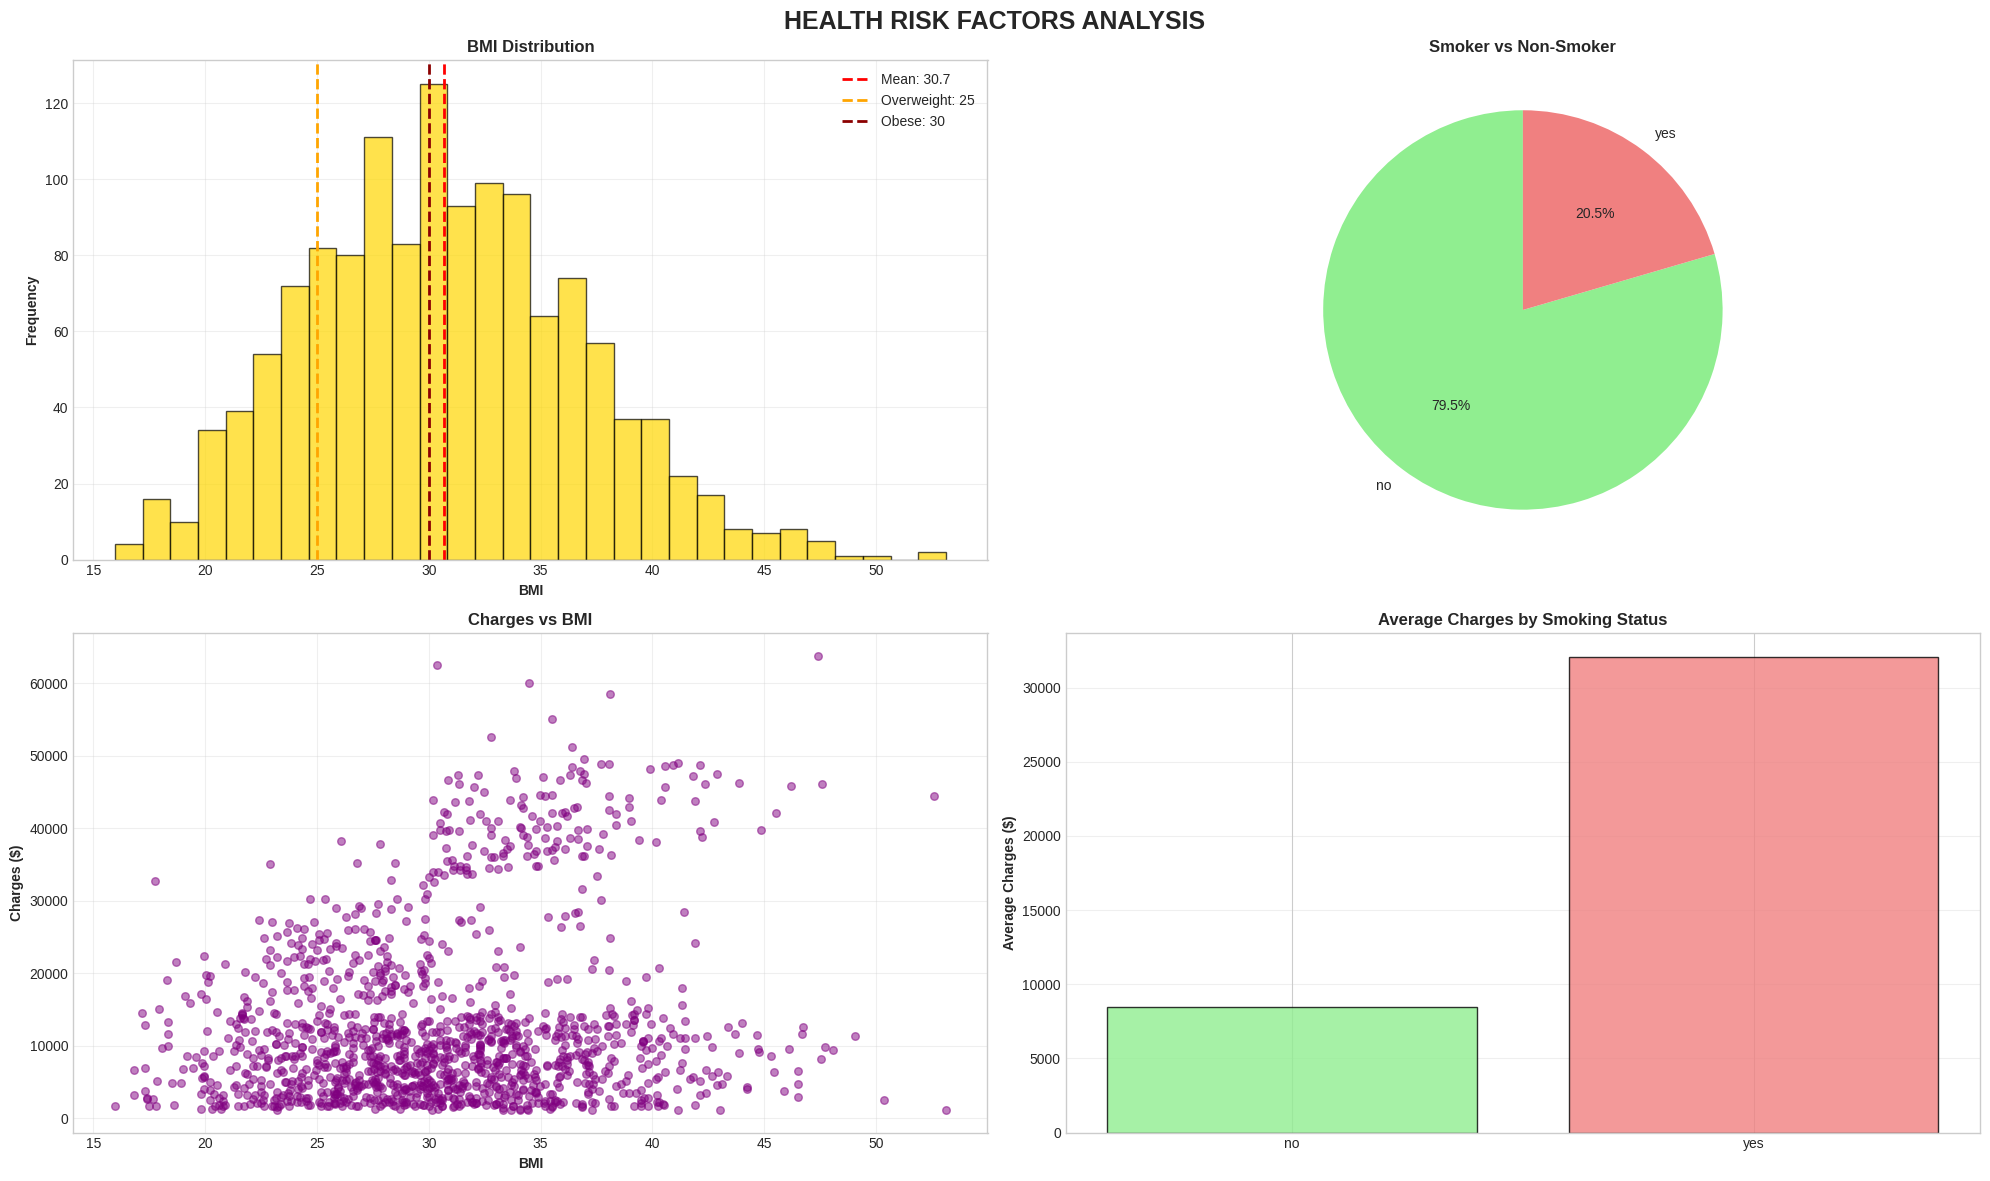

In [12]:
print('='*80)
print('HEALTH RISK FACTORS')
print('='*80)

fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle('HEALTH RISK FACTORS ANALYSIS', fontsize=18, fontweight='bold')

# BMI distribution
if 'bmi' in df.columns:
    print(f'BMI Statistics:')
    print(f'  Average: {df["bmi"].mean():.2f}')
    print(f'  Min: {df["bmi"].min():.2f}')
    print(f'  Max: {df["bmi"].max():.2f}')

    axes[0, 0].hist(df['bmi'], bins=30, color='gold', edgecolor='black', alpha=0.7)
    axes[0, 0].axvline(df['bmi'].mean(), color='red', linestyle='--', linewidth=2,
                      label=f'Mean: {df["bmi"].mean():.1f}')
    axes[0, 0].axvline(25, color='orange', linestyle='--', linewidth=2, label='Overweight: 25')
    axes[0, 0].axvline(30, color='darkred', linestyle='--', linewidth=2, label='Obese: 30')
    axes[0, 0].set_xlabel('BMI', fontweight='bold')
    axes[0, 0].set_ylabel('Frequency', fontweight='bold')
    axes[0, 0].set_title('BMI Distribution', fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)

# Smoking distribution
if 'smoker' in df.columns:
    smoker_counts = df['smoker'].value_counts()
    print(f'\nSmoking Distribution:')
    print(smoker_counts)

    axes[0, 1].pie(smoker_counts.values, labels=smoker_counts.index,
                   autopct='%1.1f%%', colors=['lightgreen', 'lightcoral'], startangle=90)
    axes[0, 1].set_title('Smoker vs Non-Smoker', fontweight='bold')

# Charges vs BMI
if 'bmi' in df.columns and charges_cols:
    axes[1, 0].scatter(df['bmi'], df[charges_col], alpha=0.5, s=30, color='purple')
    axes[1, 0].set_xlabel('BMI', fontweight='bold')
    axes[1, 0].set_ylabel('Charges ($)', fontweight='bold')
    axes[1, 0].set_title('Charges vs BMI', fontweight='bold')
    axes[1, 0].grid(alpha=0.3)

# Charges by smoking status
if 'smoker' in df.columns and charges_cols:
    smoker_charges = df.groupby('smoker')[charges_col].mean()
    axes[1, 1].bar(range(len(smoker_charges)), smoker_charges.values,
                   color=['lightgreen', 'lightcoral'], edgecolor='black', alpha=0.8)
    axes[1, 1].set_xticks(range(len(smoker_charges)))
    axes[1, 1].set_xticklabels(smoker_charges.index)
    axes[1, 1].set_ylabel('Average Charges ($)', fontweight='bold')
    axes[1, 1].set_title('Average Charges by Smoking Status', fontweight='bold')
    axes[1, 1].grid(axis='y', alpha=0.3)

    print(f'\nCharges Impact:')
    print(f'  Non-smoker avg: ${smoker_charges.iloc[0]:,.2f}')
    print(f'  Smoker avg: ${smoker_charges.iloc[1]:,.2f}')
    print(f'  Difference: ${smoker_charges.iloc[1] - smoker_charges.iloc[0]:,.2f}')
    print(f'  Multiplier: {smoker_charges.iloc[1] / smoker_charges.iloc[0]:.2f}x')

plt.tight_layout()
plt.show()

### Regional Analysis

REGIONAL ANALYSIS
Patients by Region:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

Average Charges by Region:
region
southeast   14735.41
northeast   13406.38
northwest   12417.58
southwest   12346.94
Name: charges, dtype: float64


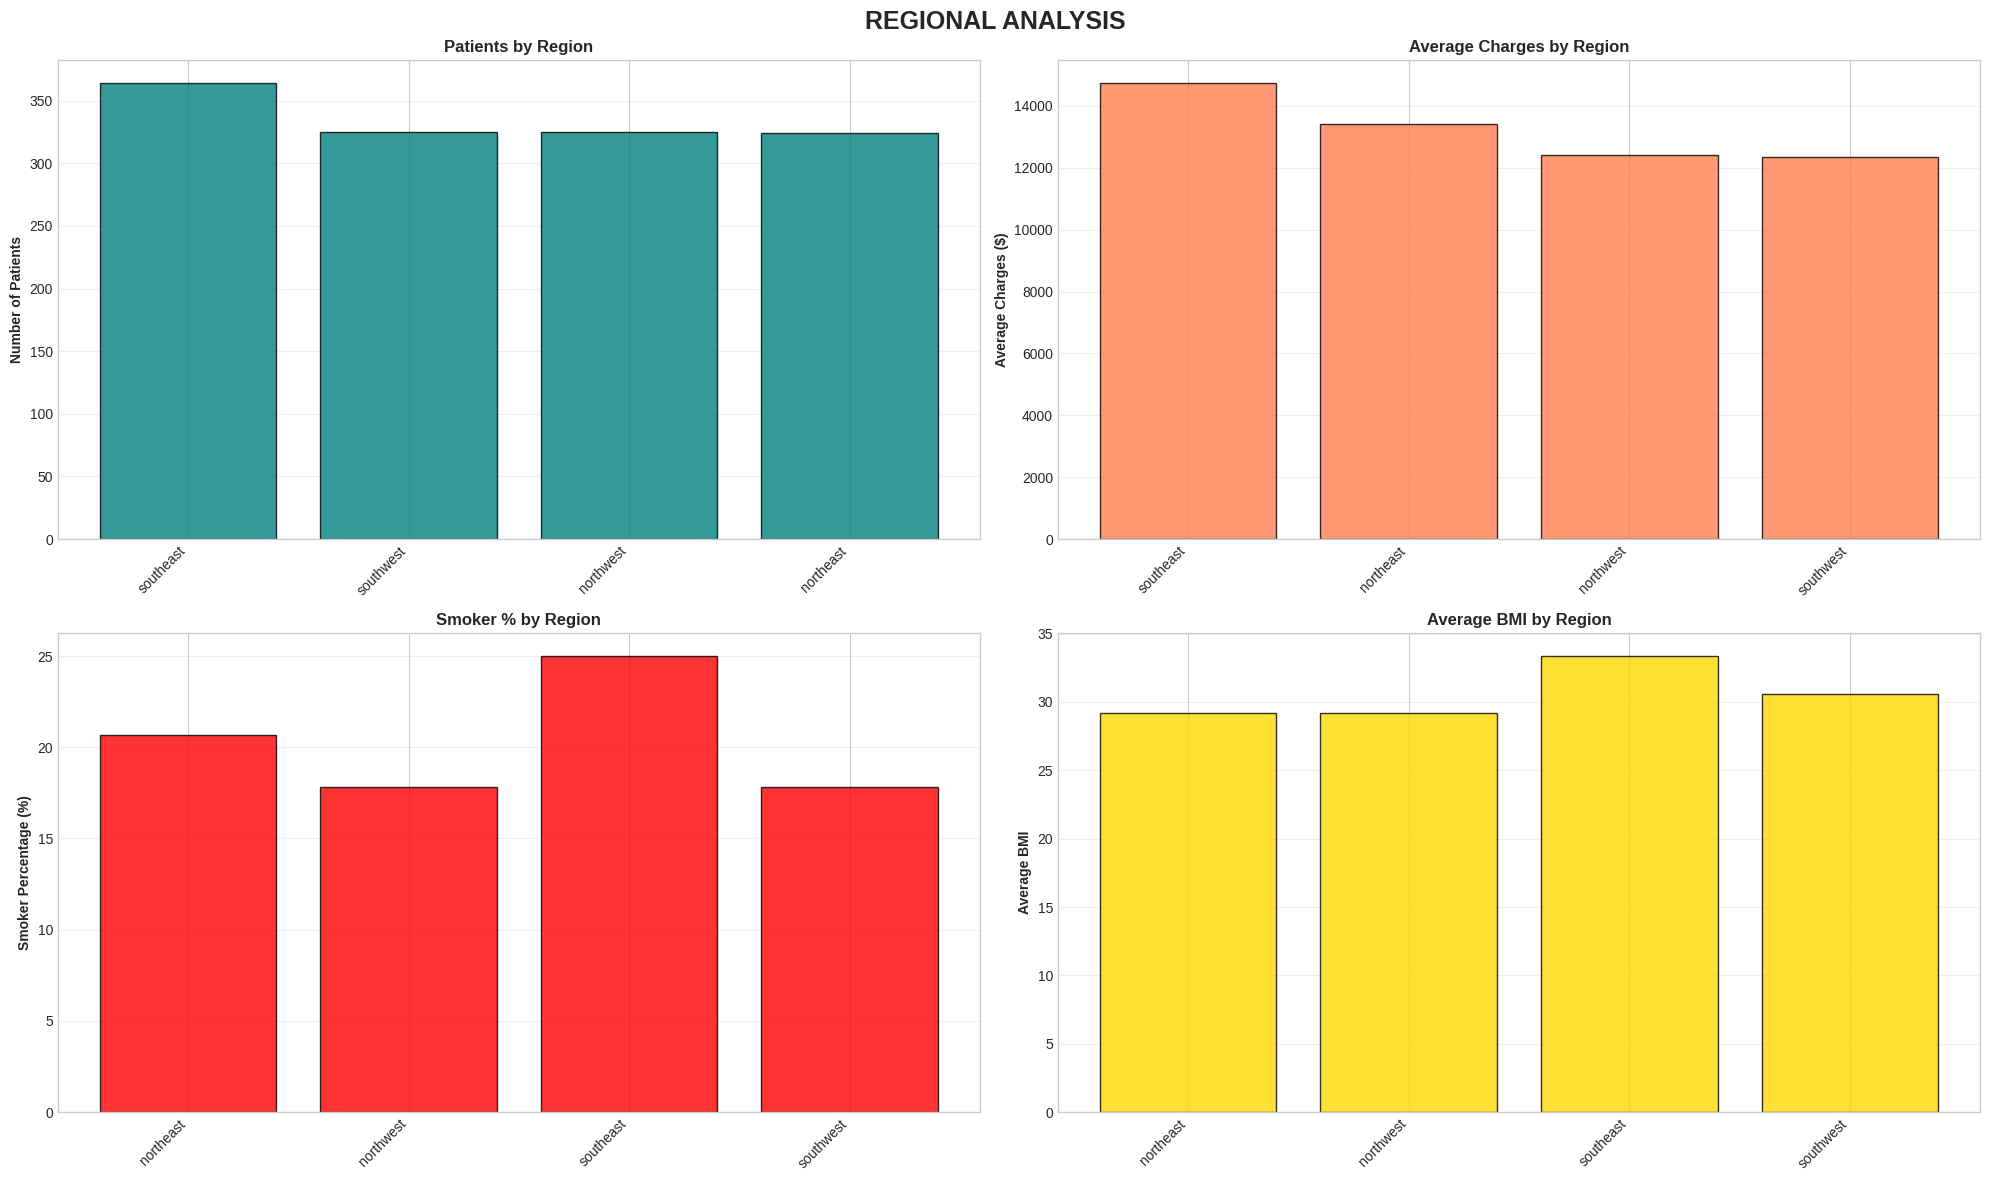

In [13]:
if 'region' in df.columns:
    print('='*80)
    print('REGIONAL ANALYSIS')
    print('='*80)

    region_counts = df['region'].value_counts()
    print('Patients by Region:')
    print(region_counts)

    fig, axes = plt.subplots(2, 2, figsize=(20, 12))
    fig.suptitle('REGIONAL ANALYSIS', fontsize=18, fontweight='bold')

    # Region distribution
    axes[0, 0].bar(range(len(region_counts)), region_counts.values,
                   color='teal', edgecolor='black', alpha=0.8)
    axes[0, 0].set_xticks(range(len(region_counts)))
    axes[0, 0].set_xticklabels(region_counts.index, rotation=45, ha='right')
    axes[0, 0].set_ylabel('Number of Patients', fontweight='bold')
    axes[0, 0].set_title('Patients by Region', fontweight='bold')
    axes[0, 0].grid(axis='y', alpha=0.3)

    # Average charges by region
    if charges_cols:
        region_charges = df.groupby('region')[charges_col].mean().sort_values(ascending=False)
        print('\nAverage Charges by Region:')
        print(region_charges)

        axes[0, 1].bar(range(len(region_charges)), region_charges.values,
                      color='coral', edgecolor='black', alpha=0.8)
        axes[0, 1].set_xticks(range(len(region_charges)))
        axes[0, 1].set_xticklabels(region_charges.index, rotation=45, ha='right')
        axes[0, 1].set_ylabel('Average Charges ($)', fontweight='bold')
        axes[0, 1].set_title('Average Charges by Region', fontweight='bold')
        axes[0, 1].grid(axis='y', alpha=0.3)

    # Smoker percentage by region
    if 'smoker' in df.columns:
        region_smokers = df.groupby('region')['smoker'].apply(lambda x: (x == 'yes').sum() / len(x) * 100)

        axes[1, 0].bar(range(len(region_smokers)), region_smokers.values,
                      color='red', edgecolor='black', alpha=0.8)
        axes[1, 0].set_xticks(range(len(region_smokers)))
        axes[1, 0].set_xticklabels(region_smokers.index, rotation=45, ha='right')
        axes[1, 0].set_ylabel('Smoker Percentage (%)', fontweight='bold')
        axes[1, 0].set_title('Smoker % by Region', fontweight='bold')
        axes[1, 0].grid(axis='y', alpha=0.3)

    # Average BMI by region
    if 'bmi' in df.columns:
        region_bmi = df.groupby('region')['bmi'].mean()

        axes[1, 1].bar(range(len(region_bmi)), region_bmi.values,
                      color='gold', edgecolor='black', alpha=0.8)
        axes[1, 1].set_xticks(range(len(region_bmi)))
        axes[1, 1].set_xticklabels(region_bmi.index, rotation=45, ha='right')
        axes[1, 1].set_ylabel('Average BMI', fontweight='bold')
        axes[1, 1].set_title('Average BMI by Region', fontweight='bold')
        axes[1, 1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

## 4. FEATURE ENGINEERING - HEALTHCARE SPECIFIC

In [14]:
print('='*80)
print('FEATURE ENGINEERING - HEALTHCARE ANALYTICS')
print('='*80)

df_clean = df.copy()

# 1. Age groups
if 'age' in df_clean.columns:
    df_clean['age_group'] = pd.cut(df_clean['age'],
                                   bins=[0, 30, 40, 50, 100],
                                   labels=['Young', 'MiddleAge', 'Senior', 'Elderly'])
    print('age_group: Created')

# 2. BMI categories
if 'bmi' in df_clean.columns:
    df_clean['bmi_category'] = pd.cut(df_clean['bmi'],
                                      bins=[0, 18.5, 25, 30, 100],
                                      labels=['Underweight', 'Normal', 'Overweight', 'Obese'])
    print('bmi_category: Created')

# 3. High-cost patient (binary target)
if charges_cols:
    charges_threshold = df_clean[charges_col].quantile(0.75)
    df_clean['is_high_cost'] = (df_clean[charges_col] >= charges_threshold).astype(int)
    print(f'is_high_cost: Created (threshold: ${charges_threshold:,.2f})')

# 4. Risk score (composite)
risk_score = 0
if 'age' in df_clean.columns:
    risk_score += (df_clean['age'] - df_clean['age'].min()) / (df_clean['age'].max() - df_clean['age'].min())
if 'bmi' in df_clean.columns:
    risk_score += (df_clean['bmi'] - df_clean['bmi'].min()) / (df_clean['bmi'].max() - df_clean['bmi'].min())
if 'smoker' in df_clean.columns:
    risk_score += (df_clean['smoker'] == 'yes').astype(int) * 2  # Smoking = 2x risk
df_clean['health_risk_score'] = risk_score
print('health_risk_score: Created')

# 5. Family size
if 'children' in df_clean.columns:
    df_clean['family_size'] = df_clean['children'] + 1  # +1 for the patient
    print('family_size: Created')

# 6. Age-BMI interaction
if 'age' in df_clean.columns and 'bmi' in df_clean.columns:
    df_clean['age_bmi_interaction'] = df_clean['age'] * df_clean['bmi']
    print('age_bmi_interaction: Created')

# 7. Smoker-BMI risk
if 'smoker' in df_clean.columns and 'bmi' in df_clean.columns:
    df_clean['smoker_bmi_risk'] = (df_clean['smoker'] == 'yes').astype(int) * df_clean['bmi']
    print('smoker_bmi_risk: Created')

print(f'\nTotal columns: {len(df_clean.columns)}')
print('='*80)

FEATURE ENGINEERING - HEALTHCARE ANALYTICS
age_group: Created
bmi_category: Created
is_high_cost: Created (threshold: $16,639.91)
health_risk_score: Created
family_size: Created
age_bmi_interaction: Created
smoker_bmi_risk: Created

Total columns: 14


In [15]:
# Data cleaning
print('DATA CLEANING:')

# Missing values
missing = df_clean.isnull().sum()
if missing.sum() == 0:
    print('No missing values!')
else:
    for col in df_clean.select_dtypes(include=[np.number]).columns:
        if df_clean[col].isnull().sum() > 0:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)
    for col in df_clean.select_dtypes(include=['object', 'category']).columns:
        if df_clean[col].isnull().sum() > 0:
            df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

# Duplicates
duplicates = df_clean.duplicated().sum()
if duplicates > 0:
    df_clean = df_clean.drop_duplicates()
    print(f'{duplicates} duplicates removed')

print(f'Clean dataset: {len(df_clean):,} patients')

DATA CLEANING:
No missing values!
1 duplicates removed
Clean dataset: 1,337 patients


## 5. MODEL PREPARATION

In [16]:
print('='*80)
print('MODEL PREPARATION - HIGH COST CLASSIFICATION')
print('='*80)

# Use is_high_cost as target
if 'is_high_cost' in df_clean.columns:
    target_col = 'is_high_cost'
else:
    # Create from charges
    if charges_cols:
        median_charges = df_clean[charges_col].median()
        df_clean['is_high_cost'] = (df_clean[charges_col] >= median_charges).astype(int)
        target_col = 'is_high_cost'
    else:
        target_col = df_clean.columns[-1]

print(f'Target: {target_col}')
y = df_clean[target_col].values
print(f'Target distribution: {np.unique(y, return_counts=True)}')

# Features
X = df_clean.drop(columns=[target_col, charges_col] if charges_cols else [target_col]).copy()

# Encoding
print('\nEncoding features...')
for col in X.select_dtypes(include=['object', 'category']).columns:
    if X[col].nunique() <= 2:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        print(f'  Binary: {col}')
    elif X[col].nunique() <= 10:
        X = pd.get_dummies(X, columns=[col], drop_first=True)
        print(f'  One-hot: {col}')
    else:
        X = X.drop(columns=[col])
        print(f'  Dropped (high cardinality): {col}')

print(f'\nFeatures: {X.shape[1]}')
print(f'Samples: {len(X):,}')
print('='*80)

MODEL PREPARATION - HIGH COST CLASSIFICATION
Target: is_high_cost
Target distribution: (array([0, 1]), array([1002,  335]))

Encoding features...
  Binary: sex
  Binary: smoker
  One-hot: region
  One-hot: age_group
  One-hot: bmi_category

Features: 18
Samples: 1,337


In [17]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train-Test Split:')
print(f'  Train: {len(X_train):,}')
print(f'  Test: {len(X_test):,}')

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('\nScaling: StandardScaler')

# SMOTE if needed
class_counts = np.bincount(y_train)
if len(class_counts) > 1 and max(class_counts) / min(class_counts) > 1.5:
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
    print(f'SMOTE: {len(X_train):,} -> {len(X_train_smote):,}')
else:
    X_train_smote = X_train_scaled
    y_train_smote = y_train
    print('No SMOTE needed')

Train-Test Split:
  Train: 1,069
  Test: 268

Scaling: StandardScaler
SMOTE: 1,069 -> 1,602


## 6. ML MODELS - 15+ WITH QDA!

### OZEL: QDA (Quadratic Discriminant Analysis) - SVM YERINE!
### Non-linear decision boundaries for complex health relationships!

In [18]:
# Base models
base_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Ridge Classifier': RidgeClassifier(random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=7, random_state=42, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(n_estimators=100, max_depth=7, random_state=42, verbose=-1),
    'CatBoost': CatBoostClassifier(iterations=100, depth=7, random_state=42, verbose=False),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB(),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'Extra Trees': ExtraTreesClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    'LDA': LinearDiscriminantAnalysis(),
    'Bagging': BaggingClassifier(n_estimators=100, random_state=42)
}

# QDA - Quadratic Discriminant Analysis!
qda_model = QuadraticDiscriminantAnalysis()

# Add to models
models = base_models.copy()
models['QDA (Quadratic Discriminant)'] = qda_model  # SVM YERINE!

print('='*80)
print(f'{len(models)} MODELS - QDA INSTEAD OF SVM!')
print('='*80)
for name in models.keys():
    marker = ' <<< QDA!' if 'QDA' in name else ''
    print(f'  - {name}{marker}')
print('\nQDA Features:')
print('  - Non-linear decision boundaries (quadratic)')
print('  - Better than LDA for non-linear data')
print('  - Allows different covariances per class')
print('  - Perfect for complex health relationships')
print('='*80)

15 MODELS - QDA INSTEAD OF SVM!
  - Logistic Regression
  - Ridge Classifier
  - Decision Tree
  - Random Forest
  - Gradient Boosting
  - XGBoost
  - LightGBM
  - CatBoost
  - KNN
  - Naive Bayes
  - AdaBoost
  - Extra Trees
  - LDA
  - Bagging
  - QDA (Quadratic Discriminant) <<< QDA!

QDA Features:
  - Non-linear decision boundaries (quadratic)
  - Better than LDA for non-linear data
  - Allows different covariances per class
  - Perfect for complex health relationships


In [ ]:
results = {}

print('='*80)
print('MODEL TRAINING - WITH QDA')
print('='*80)

for name, model in models.items():
    print(f'\n{name}...')

    try:
        model.fit(X_train_smote, y_train_smote)
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled) if hasattr(model, 'predict_proba') else None

        # Metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')

        roc_auc = None
        if y_pred_proba is not None:
            try:
                if len(np.unique(y_test)) == 2:
                    roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])
                else:
                    roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')
            except:
                pass

        results[name] = {
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1_Score': f1,
            'ROC_AUC': roc_auc,
            'predictions': y_pred,
            'pred_proba': y_pred_proba,
            'confusion_matrix': confusion_matrix(y_test, y_pred)
        }

        marker = ' <<< QDA!' if 'QDA' in name else ''
        print(f'  SUCCESS! Acc: {accuracy:.4f}, F1: {f1:.4f}{marker}')

    except Exception as e:
        print(f'  ERROR: {str(e)}')
        continue

print('\n' + '='*80)
print(f'TRAINING COMPLETE! {len(results)}/{len(models)} models')
print('='*80)

## 7. RESULTS - COMPREHENSIVE COMPARISON

In [ ]:
if results:
    results_df = pd.DataFrame({
        'Model': list(results.keys()),
        'Accuracy': [results[m]['Accuracy'] for m in results.keys()],
        'Precision': [results[m]['Precision'] for m in results.keys()],
        'Recall': [results[m]['Recall'] for m in results.keys()],
        'F1 Score': [results[m]['F1_Score'] for m in results.keys()],
        'ROC-AUC': [results[m]['ROC_AUC'] if results[m]['ROC_AUC'] else 0 for m in results.keys()]
    }).sort_values('F1 Score', ascending=False).reset_index(drop=True)

    print('='*120)
    print('MODEL PERFORMANCE COMPARISON - INSURANCE MEDICAL COST')
    print('='*120)
    print(results_df.to_string(index=False))
    print('='*120)

    best_model = results_df.iloc[0]['Model']
    print(f'\nBEST MODEL: {best_model}')
    print(f'  F1 Score: {results_df.iloc[0]["F1 Score"]:.4f}')
    print(f'  Accuracy: {results_df.iloc[0]["Accuracy"]:.4f}')

    # QDA performance
    qda_row = results_df[results_df['Model'].str.contains('QDA')]
    if not qda_row.empty:
        qda_rank = qda_row.index[0] + 1
        print(f'\nQDA PERFORMANCE:')
        print(f'  Rank: #{qda_rank}/{len(results_df)}')
        print(f'  F1 Score: {qda_row.iloc[0]["F1 Score"]:.4f}')
        print(f'  Accuracy: {qda_row.iloc[0]["Accuracy"]:.4f}')
        print(f'  Type: Non-linear discriminant analysis')
        print(f'  Status: SVM REPLACEMENT SUCCESS!')
else:
    print('No results!')

In [ ]:
# Visual comparison with QDA highlighted
if results:
    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    fig.suptitle('MODEL COMPARISON - WITH QDA', fontsize=18, fontweight='bold')

    metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
    colors_list = ['steelblue', 'coral', 'mediumseagreen', 'purple']

    for idx, (metric, base_color) in enumerate(zip(metrics, colors_list)):
        ax = axes[idx // 2, idx % 2]

        # Highlight QDA
        colors = []
        for model_name in results_df['Model']:
            if 'QDA' in model_name:
                colors.append('gold')  # QDA = GOLD!
            else:
                colors.append(base_color)

        bars = ax.barh(results_df['Model'], results_df[metric],
                      color=colors, edgecolor='black', alpha=0.8)

        # Extra highlight
        for i, model_name in enumerate(results_df['Model']):
            if 'QDA' in model_name:
                bars[i].set_edgecolor('red')
                bars[i].set_linewidth(3)

        ax.set_xlabel(metric, fontweight='bold')
        ax.set_title(f'{metric} Comparison (QDA = Gold)', fontweight='bold')
        ax.grid(axis='x', alpha=0.3)
        ax.invert_yaxis()

    plt.tight_layout()
    plt.show()

## 8. FINAL RESULTS & HEALTHCARE INSIGHTS

In [ ]:
print('='*100)
print('INSURANCE MEDICAL COST ANALYSIS - FINAL RESULTS')
print('='*100)

print('\n1. DATASET:')
print(f'   Total Patients: {len(df):,}')
print(f'   Features: {X.shape[1]}')
if charges_cols:
    print(f'   Total Medical Costs: ${df[charges_col].sum():,.2f}')
    print(f'   Avg Cost per Patient: ${df[charges_col].mean():,.2f}')
    print(f'   Median Cost: ${df[charges_col].median():,.2f}')

if results:
    print(f'\n2. BEST MODEL:')
    print(f'   Model: {best_model}')
    print(f'   F1 Score: {results_df.iloc[0]["F1 Score"]:.4f}')
    print(f'   Accuracy: {results_df.iloc[0]["Accuracy"]:.4f}')

    print(f'\n3. QDA PERFORMANCE:')
    if not qda_row.empty:
        print(f'   Rank: #{qda_rank}/{len(results_df)}')
        print(f'   F1 Score: {qda_row.iloc[0]["F1 Score"]:.4f}')
        print(f'   Type: Non-linear discriminant analysis')
        print(f'   vs LDA: Quadratic boundaries (more flexible)')
        print(f'   Status: SVM REPLACEMENT SUCCESS!')

    print(f'\n4. TOP 5 MODELS:')
    for idx, row in results_df.head(5).iterrows():
        marker = ' *** QDA' if 'QDA' in row['Model'] else ''
        print(f'   {idx+1}. {row["Model"]:40} F1: {row["F1 Score"]:.4f}{marker}')

print(f'\n5. HEALTHCARE INSIGHTS:')
if 'smoker' in df.columns and charges_cols:
    smoker_mult = df[df['smoker']=='yes'][charges_col].mean() / df[df['smoker']=='no'][charges_col].mean()
    print(f'   - Smoking Impact: {smoker_mult:.2f}x higher costs')
if 'bmi' in df.columns:
    obese_pct = (df['bmi'] >= 30).sum() / len(df) * 100
    print(f'   - Obesity Rate: {obese_pct:.1f}% (BMI >= 30)')
if 'age' in df.columns:
    print(f'   - Average Age: {df["age"].mean():.1f} years')
if 'children' in df.columns:
    print(f'   - Average Family Size: {df["children"].mean() + 1:.2f} people')

print(f'\n6. RECOMMENDATIONS:')
print(f'   - Use {best_model} for cost prediction')
print(f'   - QDA: Non-linear relationships in health data')
print(f'   - Target smoking cessation programs (major cost driver)')
print(f'   - BMI management for cost reduction')
print(f'   - Age-adjusted premium pricing')
print(f'   - Regional health initiatives')

print('\n' + '='*100)
print('HEALTHCARE ANALYTICS COMPLETE!')
print('='*100)